# Marketing & Customer Data Visualization
## Matplotlib + Seaborn

This notebook answers real business questions using two datasets:
- **marketing** — daily channel performance (spend, clicks, conversions, revenue, ROI)
- **customers** — customer segments with income, spending score, and satisfaction

**Charts covered:**
- Matplotlib: line, bar, histogram, scatter
- Seaborn: lineplot, barplot, boxplot, countplot, histplot, scatterplot, heatmap
- Saving charts as PNG files

## 1. Setup

In [ ]:
%pip install seaborn matplotlib

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid")
print("Ready!")

Ready!


## 2. Load Data

Make sure both CSV files are in the same folder as this notebook.

In [4]:
marketing = pd.read_csv("ybs_marketing_ascii.csv", parse_dates=["date"])
customers = pd.read_csv("ybs_customers_ascii.csv")

print("Marketing shape:", marketing.shape)
print("Customers shape:", customers.shape)
marketing.head()

Marketing shape: (720, 9)
Customers shape: (600, 6)


,date,channel,region,spend,clicks,conversions,revenue,roi,cpc
0,2025-07-29,Search,Izmir,742.48,455,16,7116.51,9.584783,1.631824
1,2025-07-29,Social,Antalya,874.70,655,12,7533.98,8.613216,1.335420
2,2025-07-29,Email,Istanbul,231.48,281,9,7413.38,32.026007,0.823772
3,2025-07-29,Affiliate,Istanbul,355.05,295,7,2266.75,6.384312,1.203559
4,2025-07-30,Search,Izmir,1018.22,999,39,16489.41,16.194349,1.019239


In [17]:
customers.head()

,customer_id,segment,age,income,spending_score,satisfaction
0,100001,Student,22,21615,45.781434,3.578910
1,100002,Premium,52,95781,57.078922,3.120792
2,100003,Family,34,74342,47.927974,4.482648
3,100004,Family,34,67834,50.834401,3.699999
4,100005,Family,39,64815,39.202996,4.931844


## 3. Matplotlib: Line Plot

**Business question:** How does total daily revenue change over time?

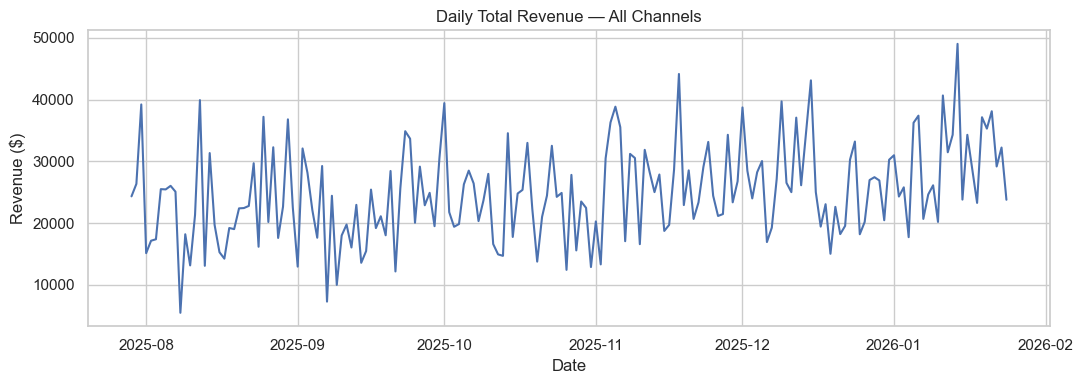

In [18]:
daily_rev = marketing.groupby("date")["revenue"].sum().reset_index()

plt.figure(figsize=(11, 4))
plt.plot(daily_rev["date"], daily_rev["revenue"], linewidth=1.5)
plt.title("Daily Total Revenue — All Channels")
plt.xlabel("Date")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()

## 4. Matplotlib: Bar Plot

**Business question:** Which channel generated the most total revenue?

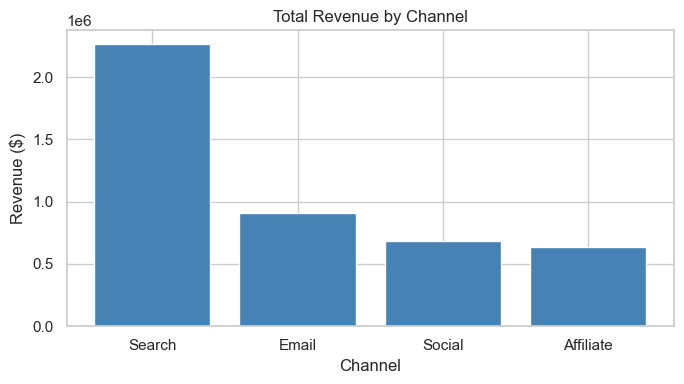

In [19]:
channel_rev = (
    marketing.groupby("channel")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(7, 4))
plt.bar(channel_rev.index, channel_rev.values, color="steelblue")
plt.title("Total Revenue by Channel")
plt.xlabel("Channel")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()

## 5. Matplotlib: Histogram

**Business question:** What does the distribution of daily revenue look like?  
Is it roughly normal or skewed?

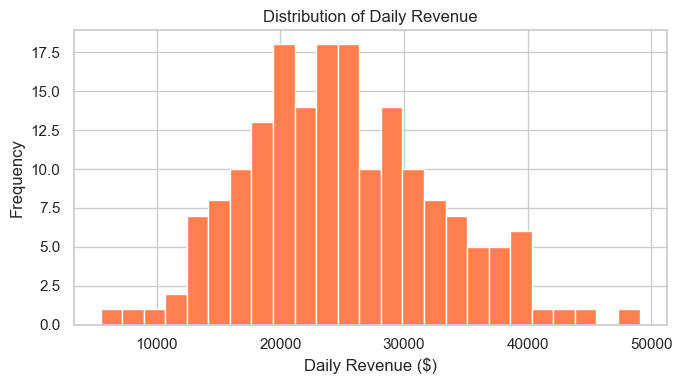

In [20]:
plt.figure(figsize=(7, 4))
plt.hist(daily_rev["revenue"], bins=25, color="coral", edgecolor="white")
plt.title("Distribution of Daily Revenue")
plt.xlabel("Daily Revenue ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 6. Matplotlib: Scatter Plot

**Business question:** Does higher daily ad spend lead to higher revenue?

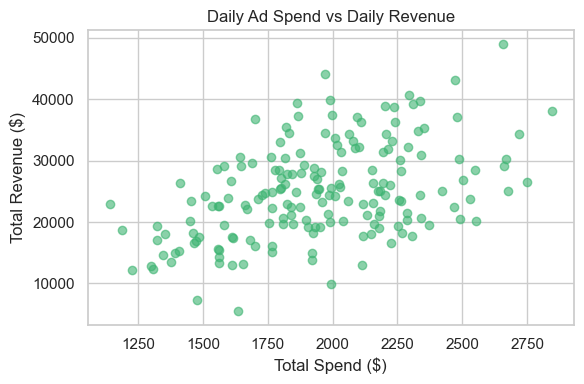

In [21]:
daily_spend = marketing.groupby("date")["spend"].sum().reset_index()
df_day      = daily_rev.merge(daily_spend, on="date")

plt.figure(figsize=(6, 4))
plt.scatter(df_day["spend"], df_day["revenue"], alpha=0.6, color="mediumseagreen")
plt.title("Daily Ad Spend vs Daily Revenue")
plt.xlabel("Total Spend ($)")
plt.ylabel("Total Revenue ($)")
plt.tight_layout()
plt.show()

## 7. Seaborn Charts

Seaborn builds on Matplotlib and makes grouped/statistical charts much faster to create.

### 7.1 Lineplot — Revenue Trend by Channel

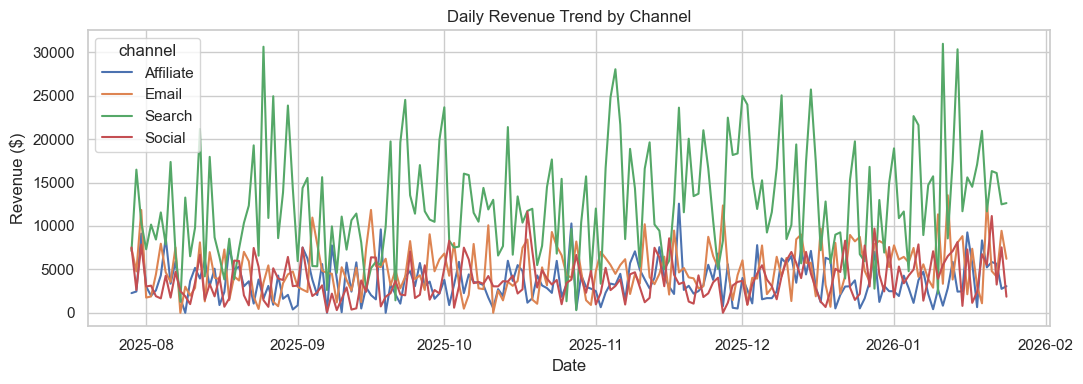

In [22]:
daily_channel = (
    marketing.groupby(["date", "channel"])["revenue"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(11, 4))
sns.lineplot(data=daily_channel, x="date", y="revenue", hue="channel", linewidth=1.5)
plt.title("Daily Revenue Trend by Channel")
plt.xlabel("Date")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()

### 7.2 Barplot — Average ROI by Channel

ROI = revenue / spend. Higher ROI means more return per dollar spent.


/var/folders/_p/q81w46n1415_ly8z13fdplyr0000gn/T/ipykernel_91911/3798561335.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=roi_by_channel, x="channel", y="roi", palette="Blues_d")


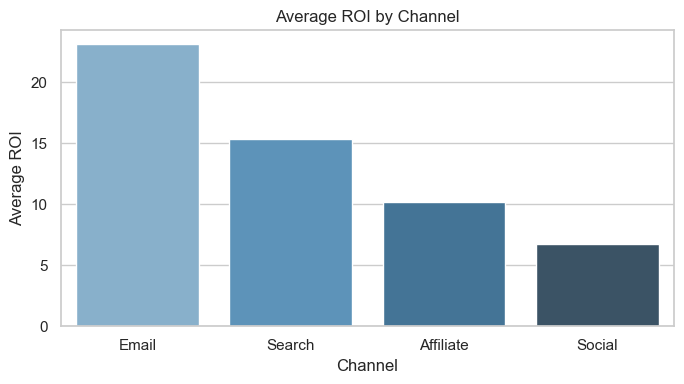

In [23]:
roi_by_channel = (
    marketing.groupby("channel")["roi"]
    .mean()
    .reset_index()
    .sort_values("roi", ascending=False)
)

plt.figure(figsize=(7, 4))
sns.barplot(data=roi_by_channel, x="channel", y="roi", palette="Blues_d")
plt.title("Average ROI by Channel")
plt.xlabel("Channel")
plt.ylabel("Average ROI")
plt.tight_layout()
plt.show()


### 7.3 Boxplot — ROI Distribution by Channel

Boxplots reveal the spread and outliers in ROI for each channel.

/var/folders/_p/q81w46n1415_ly8z13fdplyr0000gn/T/ipykernel_91911/303667960.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=marketing, x="channel", y="roi", palette="Set2")


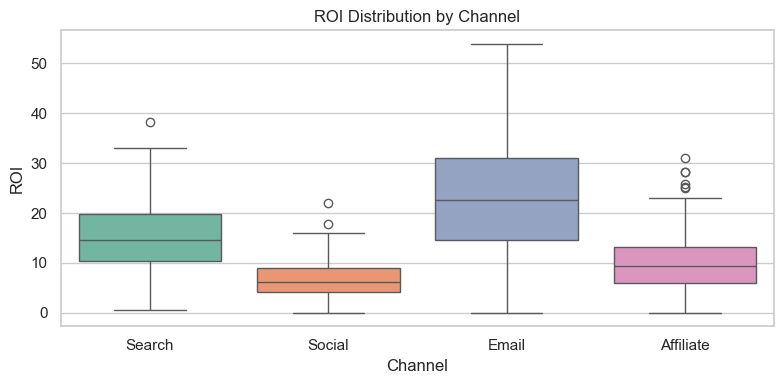

In [24]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=marketing, x="channel", y="roi", palette="Set2")
plt.title("ROI Distribution by Channel")
plt.xlabel("Channel")
plt.ylabel("ROI")
plt.tight_layout()
plt.show()

### 7.4 Countplot — Record Count by Region

/var/folders/_p/q81w46n1415_ly8z13fdplyr0000gn/T/ipykernel_91911/3090541626.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=marketing, x="region", order=region_order, palette="muted")


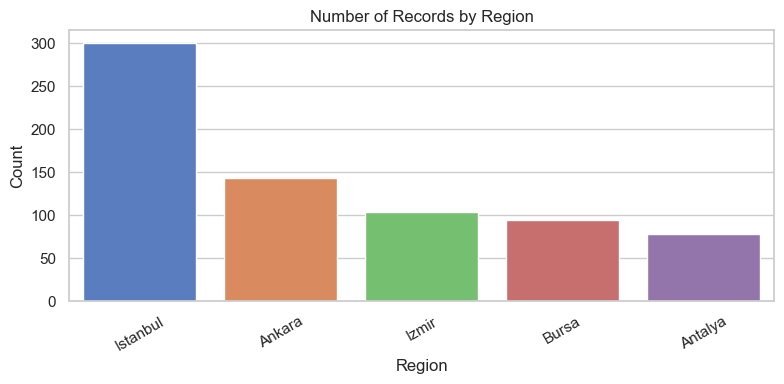

In [25]:
region_order = (
    marketing["region"].value_counts().index.tolist()
)

plt.figure(figsize=(8, 4))
sns.countplot(data=marketing, x="region", order=region_order, palette="muted")
plt.title("Number of Records by Region")
plt.xlabel("Region")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 8. Customer Segment Analysis

### 8.1 Income Distribution

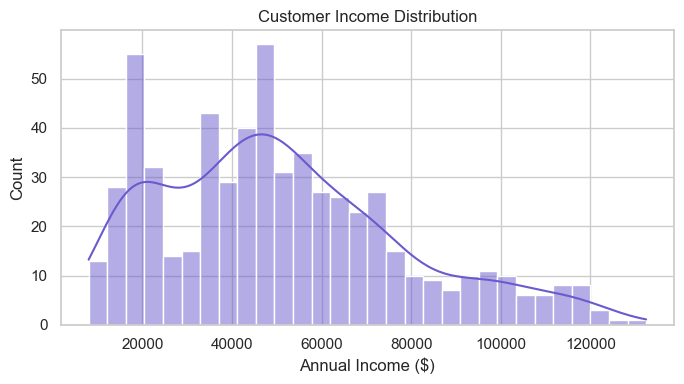

In [26]:
plt.figure(figsize=(7, 4))
sns.histplot(data=customers, x="income", bins=30, kde=True, color="slateblue")
plt.title("Customer Income Distribution")
plt.xlabel("Annual Income ($)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 8.2 Income vs Spending Score by Segment

**Business question:** Do higher-income customers necessarily spend more?

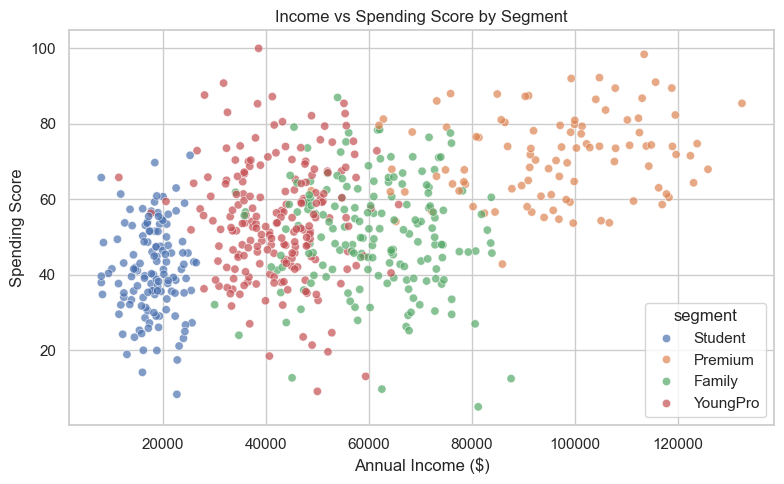

In [27]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=customers,
    x="income", y="spending_score",
    hue="segment", alpha=0.7
)
plt.title("Income vs Spending Score by Segment")
plt.xlabel("Annual Income ($)")
plt.ylabel("Spending Score")
plt.tight_layout()
plt.show()

### 8.3 Average Satisfaction by Segment

/var/folders/_p/q81w46n1415_ly8z13fdplyr0000gn/T/ipykernel_91911/4109599426.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=seg_sat, x="segment", y="satisfaction", palette="coolwarm")


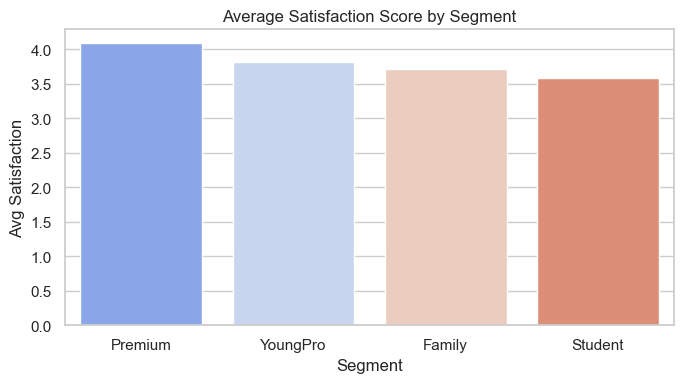

In [28]:
seg_sat = (
    customers.groupby("segment")["satisfaction"]
    .mean()
    .reset_index()
    .sort_values("satisfaction", ascending=False)
)

plt.figure(figsize=(7, 4))
sns.barplot(data=seg_sat, x="segment", y="satisfaction", palette="coolwarm")
plt.title("Average Satisfaction Score by Segment")
plt.xlabel("Segment")
plt.ylabel("Avg Satisfaction")
plt.tight_layout()
plt.show()

## 9. Correlation Heatmap — Marketing Variables

Which marketing metrics are most strongly correlated with revenue?

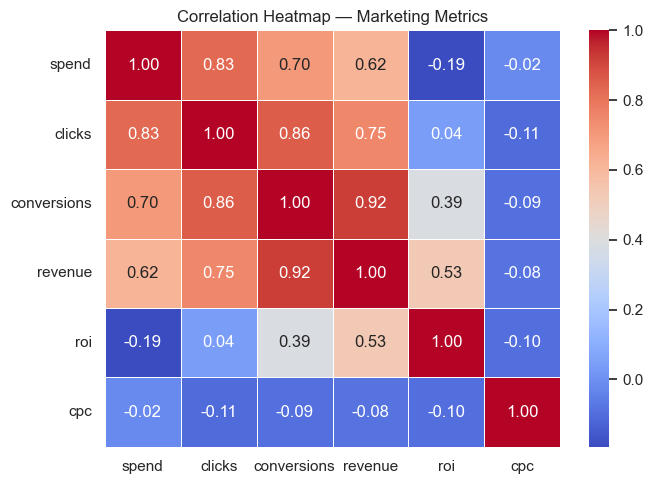

In [29]:
corr_cols = ["spend", "clicks", "conversions", "revenue", "roi", "cpc"]
corr      = marketing[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap — Marketing Metrics")
plt.tight_layout()
plt.show()

## 10. Save a Chart as PNG

Saved: avg_roi_by_channel.png


/var/folders/_p/q81w46n1415_ly8z13fdplyr0000gn/T/ipykernel_91911/3852399225.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=roi_by_channel, x="channel", y="roi", palette="Blues_d")


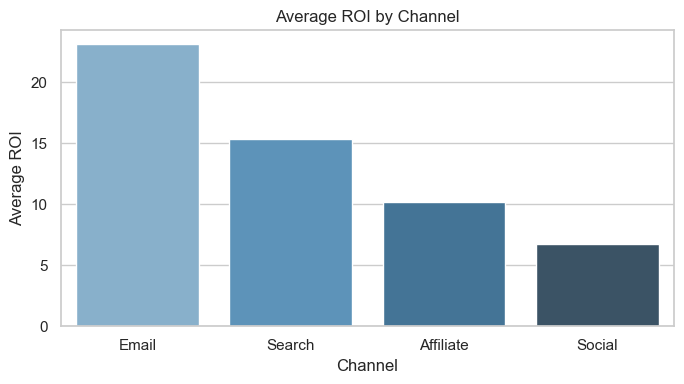

In [30]:
plt.figure(figsize=(7, 4))
sns.barplot(data=roi_by_channel, x="channel", y="roi", palette="Blues_d")
plt.title("Average ROI by Channel")
plt.xlabel("Channel")
plt.ylabel("Average ROI")
plt.tight_layout()

plt.savefig("avg_roi_by_channel.png", dpi=150)
print("Saved: avg_roi_by_channel.png")
plt.show()

## Summary

| Chart type | Library | Business question answered |
|---|---|---|
| Line | Matplotlib | Revenue trend over time |
| Bar | Matplotlib | Best channel by total revenue |
| Histogram | Matplotlib | Revenue distribution shape |
| Scatter | Matplotlib | Spend vs revenue relationship |
| Lineplot | Seaborn | Revenue trend per channel |
| Barplot | Seaborn | Average ROI per channel |
| Boxplot | Seaborn | ROI spread and outliers |
| Countplot | Seaborn | Record count by region |
| Histplot + KDE | Seaborn | Income distribution |
| Scatterplot | Seaborn | Income vs spending by segment |
| Heatmap | Seaborn | Metric correlations |